In [28]:
import numpy as np 
base_path = "/home/seungwoochoi/data/axis_rag/train/"

a = np.load(base_path + "results/q_dim_weight_list_2_30_True_0.0_0.0003.npy")

print(a.shape)
print(10047*1024)
print(np.where(a <= 0.0)[1].shape)

cumulative_count = []

for i in [0.0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]:
    cumulative_count.append(np.where(a[0,:] <= i)[0].shape[0])

cumulative_count

(10047, 1024)
10288128
(22543,)


[4,
 22,
 22,
 22,
 23,
 23,
 24,
 24,
 24,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 26,
 28,
 1024]

In [3]:
#a의 행별로 값이 작은 20개 index 계산
topk_indices = np.argsort(a, axis=1)[:1000,:30]
topk_indices

# top_k_indices의 각 행끼리 교집합 개수의 평균 계산
intersection_counts = []
num_rows = topk_indices.shape[0]
for i in range(num_rows):
    for j in range(i + 1, num_rows):
        intersection = np.intersect1d(topk_indices[i], topk_indices[j])
        intersection_counts.append(len(intersection))

average_intersection = np.mean(intersection_counts)
average_intersection


np.float64(21.361593593593593)

In [4]:
np.where(a == 1.0)[0].shape


(9373578,)

In [5]:
9373578 /10288128 

0.9111062770603165

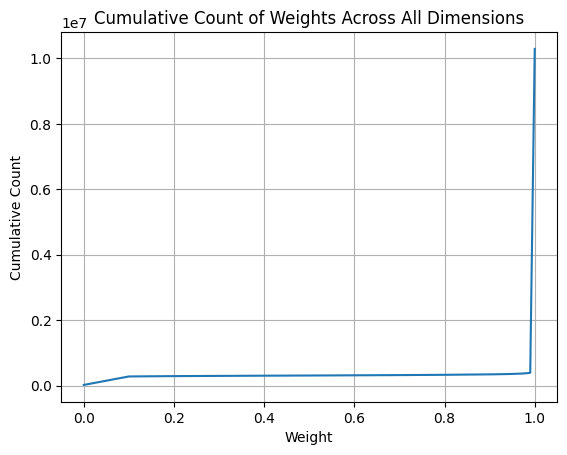

0.027352886744799444


In [6]:
#visualization 
import matplotlib.pyplot as plt
plt.plot([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0], cumulative_count)
plt.xlabel("Weight")
plt.ylabel("Cumulative Count")
plt.title("Cumulative Count of Weights Across All Dimensions")
plt.grid()
plt.show()

print(281410/10288128)

KeyboardInterrupt: 

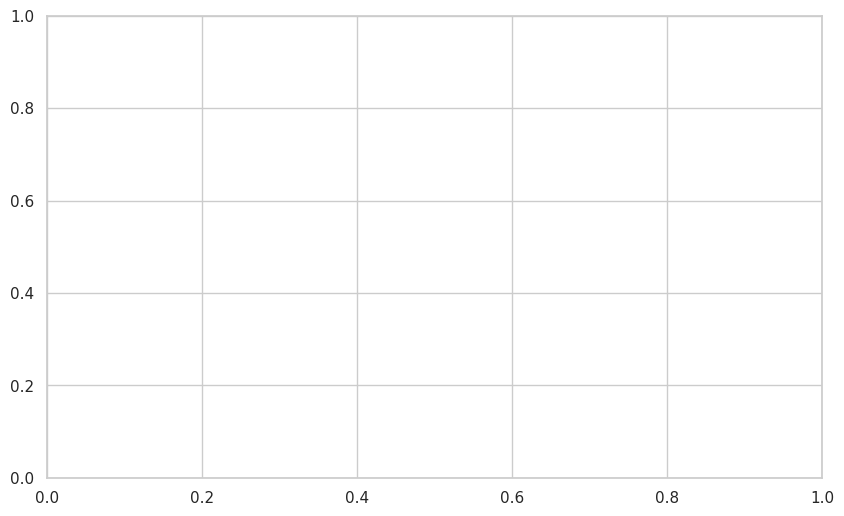

In [7]:

#누적 분포 plot
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(a, bins=100, kde=True, stat="density", color="skyblue", edgecolor="black")
plt.title("Dimension Weights Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.axvline(np.mean(a), color='red', linestyle='dashed', linewidth=1)
plt.text(np.mean(a), plt.ylim()[1]*0.9, 'Mean: {:.2f}'.format(np.mean(a)), color='red')
plt.show()

(310252,)
Correlation Coefficient: 0.0008726053712154415


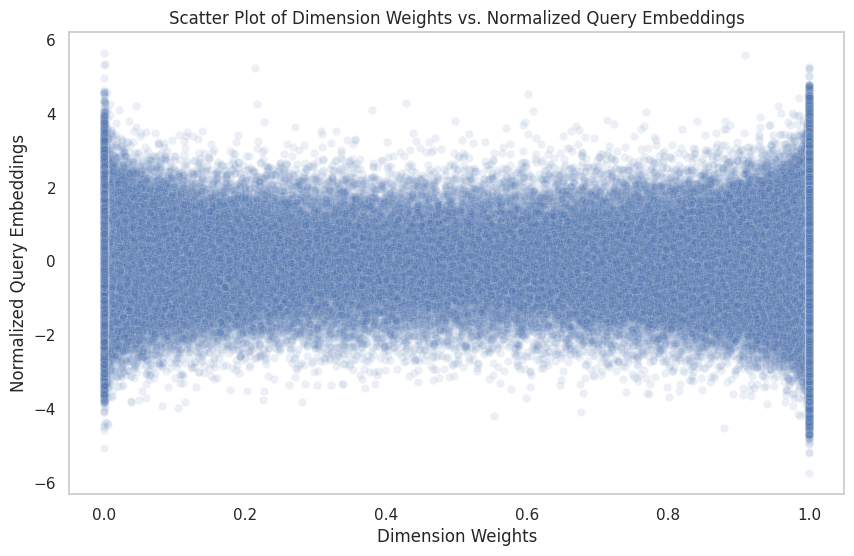

In [27]:
b = np.load(base_path + "results/query_emb_normalized_list_2_30_True_0.0_0.0003.npy")
b_flatten = b.reshape(1, -1)
b_flatten_abs = np.abs(b.reshape(1, -1))
a_flatten = a.reshape(1, -1)

print(np.where(a_flatten <= 0.5)[1].shape)

# 두 배열의 상관계수 계산
correlation_matrix = np.corrcoef(a_flatten, b_flatten_abs)
correlation_coefficient = correlation_matrix[0, 1]
print("Correlation Coefficient:", correlation_coefficient)

# Scatter plot 
plt.figure(figsize=(10, 6))
sns.scatterplot(x=a_flatten.flatten(), y=b_flatten.flatten(), alpha=0.1)
plt.title("Scatter Plot of Dimension Weights vs. Normalized Query Embeddings")
plt.xlabel("Dimension Weights")
plt.ylabel("Normalized Query Embeddings")
plt.grid()
plt.show()